# Evaluación Parcial N°1: Clasificación de Lenguaje de Señas (ASL) mediante MLP

## FASE 1: Comprensión del Negocio (Business Understanding)

* **Problema de Negocio:** Las personas con discapacidad auditiva enfrentan barreras de comunicación significativas. Se requiere desarrollar un sistema de visión computacional accesible que permita traducir gestos del alfabeto de la lengua de señas a texto en tiempo real, facilitando la inclusión.
* **Objetivo del Proyecto:** Implementar, entrenar y evaluar una Red Neuronal Densa (MLP) capaz de clasificar imágenes de 28x28 píxeles en 24 clases del Alfabeto de Lengua de Señas Americano (excluyendo J y Z).
* **Justificación del Dataset:** Se utiliza "Sign Language MNIST" (Kaggle), un benchmark estándar de reconocimiento del alfabeto de señas ASL: imágenes en escala de grises de 28×28 px y 24 clases (sin J ni Z, que requieren movimiento). Su tamaño moderado (27.455 imágenes de entrenamiento) permite experimentar con MLP en pocos minutos y sus clases visualmente similares (M/S, U/K) dan material claro para el análisis de errores. Corresponde a la categoría "reconocer letras del lenguaje de señas" de las opciones de la evaluación.
* **Variante Propia:** Para evitar reproducir resultados estándar, este proyecto entrenará los modelos utilizando **solo una muestra aleatoria estratificada del 50% del set de entrenamiento original** (fijada por semilla). Esto emula un escenario de recursos o datos limitados, exigiendo mayor robustez en la configuración del modelo.
* **KPIs Objetivo:**
  * **Accuracy Global en Test:** $\ge 80\%$.
  * **F1-Score Macro:** $\ge 75\%$, para asegurar que las clases más difíciles anatómicamente se clasifiquen correctamente de manera equilibrada.

### Evaluación de Impacto Ético
* **Sesgos de Representación:** Las imágenes de este dataset provienen de simulaciones bajo iluminación controlada y recortes centrados. Un modelo entrenado aquí podría fallar o sesgarse en el mundo real frente a distintos tonos de piel, fondos desordenados (clutter) o variaciones de iluminación, lo que requiere ser abordado en futuras fases (Data Augmentation o CNNs).

In [12]:
# Importación de librerías
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Trazabilidad: Fijar TODAS las semillas globales
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## FASE 2: Comprensión de los Datos (Data Understanding / EDA)

Se procede a cargar los archivos `sign_mnist_train.csv` y `sign_mnist_test.csv` desde la carpeta `data/`. Es vital mantener el set de prueba aislado hasta la evaluación final. Si dividimos un único archivo aleatoriamente, el modelo sufriría de *Data Leakage* (Fuga de datos), ya que muchas imágenes son aumentaciones casi idénticas de la misma mano original, logrando un accuracy irreal del 100% en validación.

In [13]:
# Carga de datos reales (Asegúrate de colocar los archivos en la carpeta 'data/')
df_train_full = pd.read_csv('data/sign_mnist_train.csv')
df_test = pd.read_csv('data/sign_mnist_test.csv')

# Define valid labels (excluding J=9 and Z=25 as per problem statement)
# The original dataset labels range from 0-24, where 9 corresponds to 'J'. 'Z' (label 25) is not typically in this dataset.
valid_labels = sorted(list(set(range(25)) - {9})) # Creates [0, 1, ..., 8, 10, ..., 24]

# Filter dataframes to only include valid labels
df_train_full_filtered = df_train_full[df_train_full['label'].isin(valid_labels)].copy()
df_test_filtered = df_test[df_test['label'].isin(valid_labels)].copy()

print(f"Dimensiones Train original (filtrado): {df_train_full_filtered.shape}")
print(f"Dimensiones Test (filtrado): {df_test_filtered.shape}")

# Verificación de nulos y duplicados en datos filtrados
print(f"Valores nulos en train (filtrado): {df_train_full_filtered.isnull().sum().sum()}")
print(f"Duplicados en train (filtrado): {df_train_full_filtered.duplicated().sum()}")

# Mapeo de etiquetas (Faltan J=9 y Z=25 - ahora filtradas de los datos)
alphabet = "ABCDEFGHIKLMNOPQRSTUVWXY"
# Ensure label_mapping uses the filtered valid_labels and maps them correctly to the alphabet string
label_mapping = {valid_label: alphabet[idx] for idx, valid_label in enumerate(valid_labels)}


Dimensiones Train original (filtrado): (27455, 785)
Dimensiones Test (filtrado): (7172, 785)
Valores nulos en train (filtrado): 0
Duplicados en train (filtrado): 0


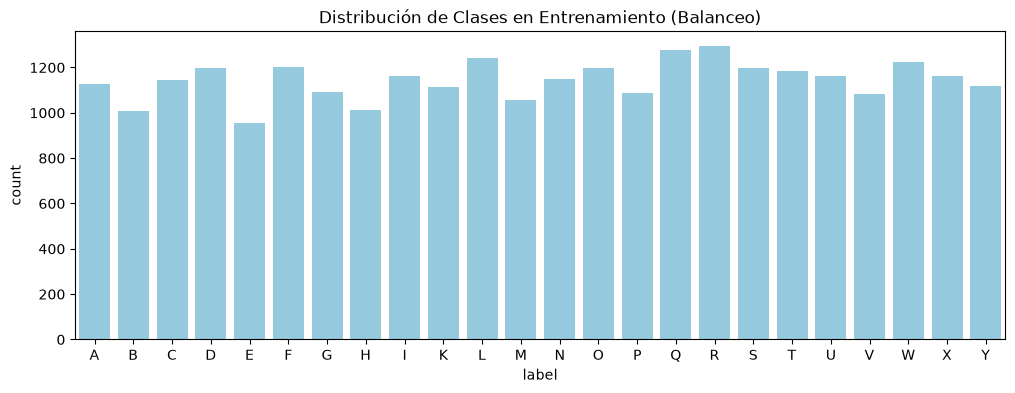

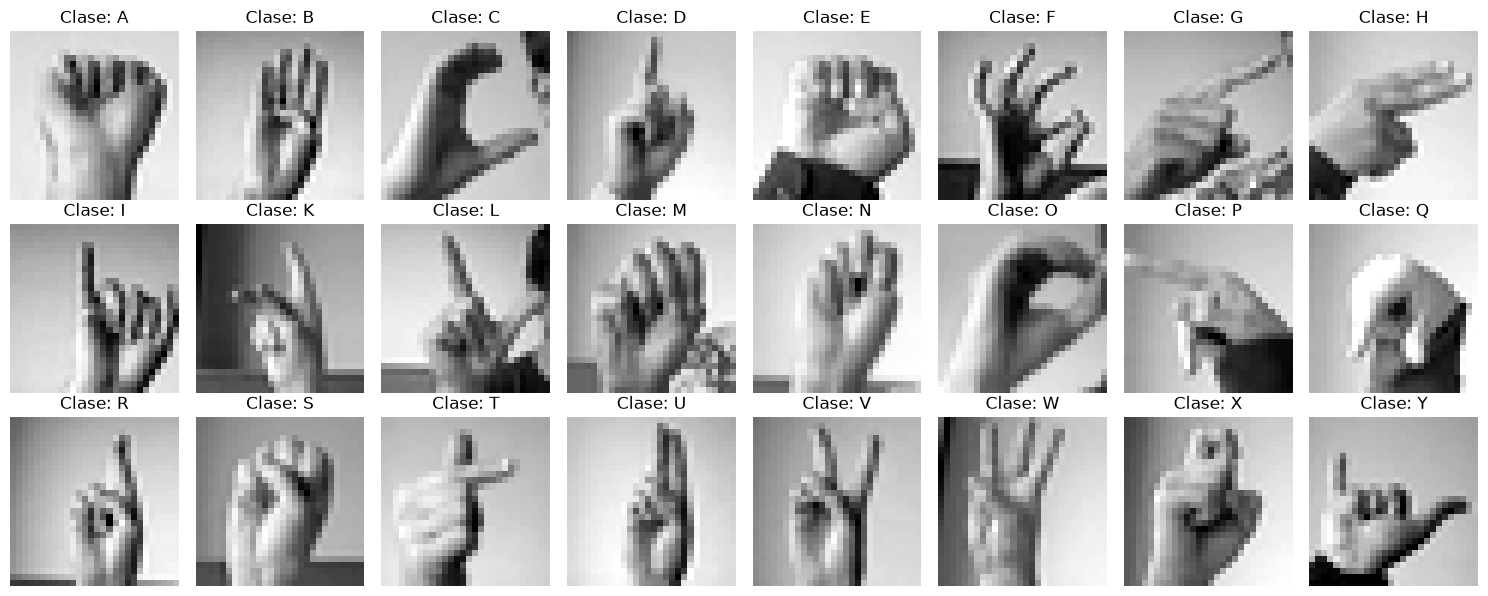

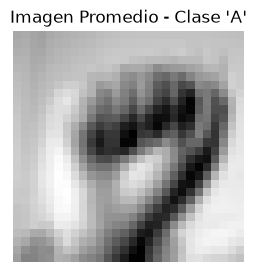

In [14]:
# EDA 1: Distribución de clases
plt.figure(figsize=(12, 4))
sns.countplot(x='label', data=df_train_full, order=sorted(df_train_full['label'].unique()), color='skyblue')
plt.title('Distribución de Clases en Entrenamiento (Balanceo)')
plt.xticks(ticks=range(24), labels=list(label_mapping.values()))
plt.savefig('images/distribucion_clases.png')
plt.show()

# EDA 2: Un ejemplo por cada clase
fig, axes = plt.subplots(3, 8, figsize=(15, 6))
axes = axes.flatten()
for i, label in enumerate(sorted(df_train_full['label'].unique())):
    # Tomar la primera imagen de cada clase
    img_data = df_train_full[df_train_full['label'] == label].iloc[0, 1:].values.reshape(28, 28)
    axes[i].imshow(img_data, cmap='gray')
    axes[i].set_title(f"Clase: {label_mapping[label]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('images/ejemplos_clases.png')
plt.show()

# EDA 3: Imagen Promedio (Ejemplo con la letra 'A')
clase_a = df_train_full[df_train_full['label'] == 0].iloc[:, 1:].values
imagen_promedio_a = np.mean(clase_a, axis=0).reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(imagen_promedio_a, cmap='gray')
plt.title("Imagen Promedio - Clase 'A'")
plt.axis('off')
plt.show()

### Hallazgos del EDA
- **Calidad de datos:** sin valores nulos ni duplicados. Los 784 píxeles están en el rango 0–255 (media ≈ 159), por lo que basta con normalizar dividiendo por 255.
- **Balance de clases:** el entrenamiento está bien balanceado (entre 957 y 1.294 imágenes por clase, razón máxima/mínima de 1,35). El test no lo está tanto (entre 144 y 498 por clase), por eso además del accuracy se revisan Precision, Recall y F1 por clase.
- **Patrones y dificultades:** varias letras son puños o manos con pocos dedos de diferencia (por ejemplo M/S y U/K/D). A 28×28 px esas diferencias ocupan muy pocos píxeles, lo que anticipa confusiones entre esas clases.
- **Variable relevante:** cada píxel es una variable de entrada; el MLP los recibe aplanados (784 valores), sin información de vecindad espacial.

## FASE 3: Preparación de Datos (Data Preparation)

1. **Variante del Proyecto:** Reducimos el set de entrenamiento al 50% con estratificación.
2. **Separación X e y.**
3. **Normalización:** Los píxeles de 0-255 se dividen por 255.0 para dejarlos en $[0, 1]$, estabilizando los gradientes durante el descenso.
4. **One-Hot Encoding:** Las etiquetas enteras se binarizan para clasificación multiclase.
5. **Split Train/Val:** Dividimos el 50% restante en Entrenamiento (80%) y Validación (20%) utilizando `stratify=y` para mantener la proporción de clases.

In [15]:
# 1. Aplicar variante (50% de los datos)
# Usar df_train_full_filtered en lugar de df_train_full
_, df_train_variant = train_test_split(df_train_full_filtered, test_size=0.50, stratify=df_train_full_filtered['label'], random_state=SEED)

# 2. Separación
X = df_train_variant.drop('label', axis=1).values
y = df_train_variant['label'].values

# Usar df_test_filtered en lugar de df_test
X_test_final = df_test_filtered.drop('label', axis=1).values / 255.0
y_test_final = df_test_filtered['label'].values

# 3. Normalización
X_norm = X / 255.0

# 4. One-Hot Encoding
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)
y_test_encoded = lb.transform(y_test_final) # Ahora y_test_final no contendrá 9

# 5. Split estratificado Train/Val
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y_encoded, test_size=0.20, stratify=y_encoded, random_state=SEED
)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}")
print(f"Test Final: X={X_test_final.shape}, y={y_test_final.shape}")


Train: X=(10982, 784), y=(10982, 24)
Validation: X=(2746, 784), y=(2746, 24)
Test Final: X=(7172, 784), y=(7172,)


## FASE 4: Modelado (Modeling) y Experimentación

Se diseñarán 3 configuraciones de MLP para comparar su rendimiento:
* **Modelo 1 (Baseline):** 1 Capa oculta (128), ReLU. Arquitectura simple para establecer la métrica base.
* **Modelo 2 (Profundo):** 2 Capas ocultas (256, 128), ReLU. Mayor capacidad para extraer patrones no lineales.
* **Modelo 3 (Profundo + Dropout):** 2 Capas (256, 128) + Dropout (0.3). El Dropout apagará aleatoriamente un 30% de las neuronas en cada paso, forzando a la red a no depender de píxeles específicos, mitigando el sobreajuste.

Hiperparámetros globales justificados:
* **Batch Size:** 64 (Balance entre actualización suave del gradiente y velocidad computacional).
* **Optimizador:** Adam (Tasa de aprendizaje adaptativa por parámetro).
* **Early Stopping:** `patience=5`. Detiene el modelo si en 5 épocas la pérdida de validación no mejora, restaurando los mejores pesos.

* **Salida y pérdida:** softmax con 24 neuronas (una por clase, probabilidades que suman 1) y `categorical_crossentropy`, coherente con etiquetas one-hot en clasificación multiclase.
* **Learning rate y épocas:** Adam con lr por defecto (0,001), que suele converger bien sin ajuste fino. Máximo de 30 épocas con early stopping, para no fijar el número a ojo.

In [16]:
def build_model_1():
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_model_2():
    model = Sequential([
        Input(shape=(784,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_model_3():
    model = Sequential([
        Input(shape=(784,)),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Callback global
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

modelos, histories = {}, {}
configs = [('Baseline (128)', build_model_1),
           ('Profundo (256-128)', build_model_2),
           ('Profundo + Dropout', build_model_3)]

for nombre, builder in configs:
    print(f"Entrenando {nombre}...")
    tf.keras.utils.set_random_seed(SEED)
    m = builder()
    histories[nombre] = m.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=30, batch_size=64, callbacks=[early_stop], verbose=0)
    modelos[nombre] = m

Entrenando Baseline (128)...
Entrenando Profundo (256-128)...
Entrenando Profundo + Dropout...


## FASE 5: Evaluación (Evaluation)

### 5.1 Comparación de Modelos
Los tres modelos se comparan con el conjunto de **validación**, que es el criterio de selección. El conjunto de **test** se usa solo de forma informativa y para el reporte final del modelo elegido, evitando fuga de información.

In [17]:
filas = []
for nombre, m in modelos.items():
    h = histories[nombre].history
    v_loss, v_acc = m.evaluate(X_val, y_val, verbose=0)
    t_loss, t_acc = m.evaluate(X_test_final, y_test_encoded, verbose=0)
    filas.append({'Modelo': nombre, 'Épocas': len(h['loss']),
                  'Val Loss': v_loss, 'Val Acc': v_acc, 'Test Acc (informativo)': t_acc})
df_comparacion = pd.DataFrame(filas)
display(df_comparacion)

# Selección por VALIDACIÓN (no por test)
mejor_nombre = df_comparacion.sort_values('Val Loss').iloc[0]['Modelo']
best_model, best_history = modelos[mejor_nombre], histories[mejor_nombre]
print(f"Mejor modelo (por Val Loss): {mejor_nombre}")
best_model.save('models/mejor_modelo_mlp.keras')

,Modelo,Épocas,Val Loss,Val Acc,Test Acc (informativo)
0,Baseline (128),30,0.410652,0.879097,0.669827
1,Profundo (256-128),30,0.028920,0.997451,0.776074
2,Profundo + Dropout,30,0.395607,0.889658,0.698132


Mejor modelo (por Val Loss): Profundo (256-128)


### 5.2 Interpretación de Curvas (Mejor Modelo: Profundo 256-128)
- **Convergencia:** el modelo entrenó las 30 épocas máximas, con su mejor val_loss en la época 28. El early stopping no llegó a activarse, señal de que la red seguía aprendiendo lentamente al final.
- **Brecha train–val:** en la mejor época el accuracy de entrenamiento es 0,991 y el de validación 0,997, es decir, no hay brecha (-0,006).
- **Lectura:** la validación (99,7%) es engañosa. El accuracy en test es 77,6%, una caída de ~22 puntos. Esto sugiere que el conjunto de validación se parece demasiado al de entrenamiento (ambos salen del mismo train, con imágenes casi idénticas de las mismas manos) y el modelo generaliza peor a manos nuevas de lo que muestra la validación. El sobreajuste real se ve al comparar validación con test, no train con validación.

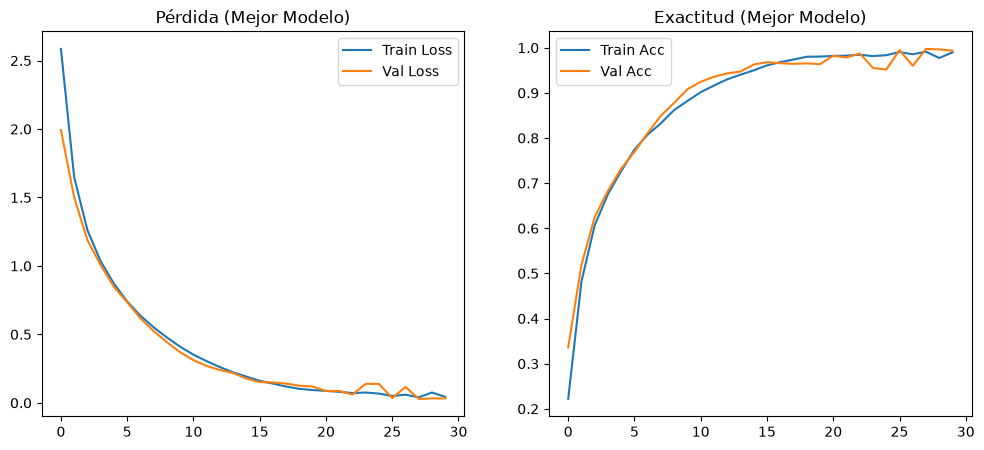

Épocas ejecutadas: 30 | Mejor época (val_loss): 28
Train acc: 0.991 | Val acc: 0.997
Brecha train-val: -0.006


In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Mejor Modelo)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['accuracy'], label='Train Acc')
plt.plot(best_history.history['val_accuracy'], label='Val Acc')
plt.title('Exactitud (Mejor Modelo)')
plt.legend()
plt.savefig('images/curvas_mejor_modelo.png')
plt.show()
h = best_history.history
ep_total = len(h['loss'])
ep_mejor = int(np.argmin(h['val_loss'])) + 1
print(f"Épocas ejecutadas: {ep_total} | Mejor época (val_loss): {ep_mejor}")
print(f"Train acc: {h['accuracy'][ep_mejor-1]:.3f} | Val acc: {h['val_accuracy'][ep_mejor-1]:.3f}")
print(f"Brecha train-val: {h['accuracy'][ep_mejor-1]-h['val_accuracy'][ep_mejor-1]:.3f}")

### 5.3 Métricas y Matriz de Confusión
* **Accuracy:** Mide el % total de aciertos.
* **Precision:** De todas las imágenes que el modelo dijo que eran 'A', ¿cuántas realmente lo eran?
* **Recall:** De todas las 'A' reales en el dataset, ¿cuántas logró encontrar el modelo?
* **F1-Score:** Media armónica entre Precision y Recall. Crucial para confirmar que ninguna clase se quedó atrás.
**Interpretación de resultados:** el accuracy global en test es 0,776 y el F1 macro 0,763, valores cercanos porque las clases están balanceadas. Las letras más difíciles son S (F1 0,51), U (0,55), T (0,61) y W (0,62). En A, la precision (0,88) es menor que el recall (1,00): el modelo la sobrepredice, y otras letras se cuelan en ella. En N, O y U ocurre lo contrario: N tiene precision 0,76 pero recall 0,53, y U tiene precision 0,66 y recall 0,47, o sea que el modelo deja escapar muchos ejemplos reales de esas letras.

**KPIs:** el KPI de F1 macro (≥ 75%) se cumple con 0,763, pero el de accuracy (≥ 80%) no, con 0,776. Causas probables: el MLP no aprovecha la estructura 2D de la imagen, se entrenó con solo el 50% de los datos y las manos del test son distintas a las del entrenamiento. Para alcanzar la meta se usaría una CNN, data augmentation o el 100% de los datos.

 44/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.776 | Precision macro: 0.771 | Recall macro: 0.769 | F1 macro: 0.763
KPI Accuracy >= 0.80: NO CUMPLIDO | KPI F1 macro >= 0.75: CUMPLIDO
              precision    recall  f1-score   support

           A       0.88      1.00      0.94       331
           B       1.00      0.81      0.90       432
           C       0.95      0.93      0.94       310
           D       0.69      0.90      0.78       245
           E       0.89      0.93      0.91       498
           F       0.73      0.91      0.81       247
           G       0.77      0.73      0.75       348
           H       0.95      0.83      0.88       436
           I       0.86      0.85      0.85       288
           K       0.64      0.69      0.66       331
           L       0.80      0.87      0.83       209
           M       0.82      0.72      0.77       394
           N       0.76      0.53      0.63       291
           O       0.99      0.70      0.82       246


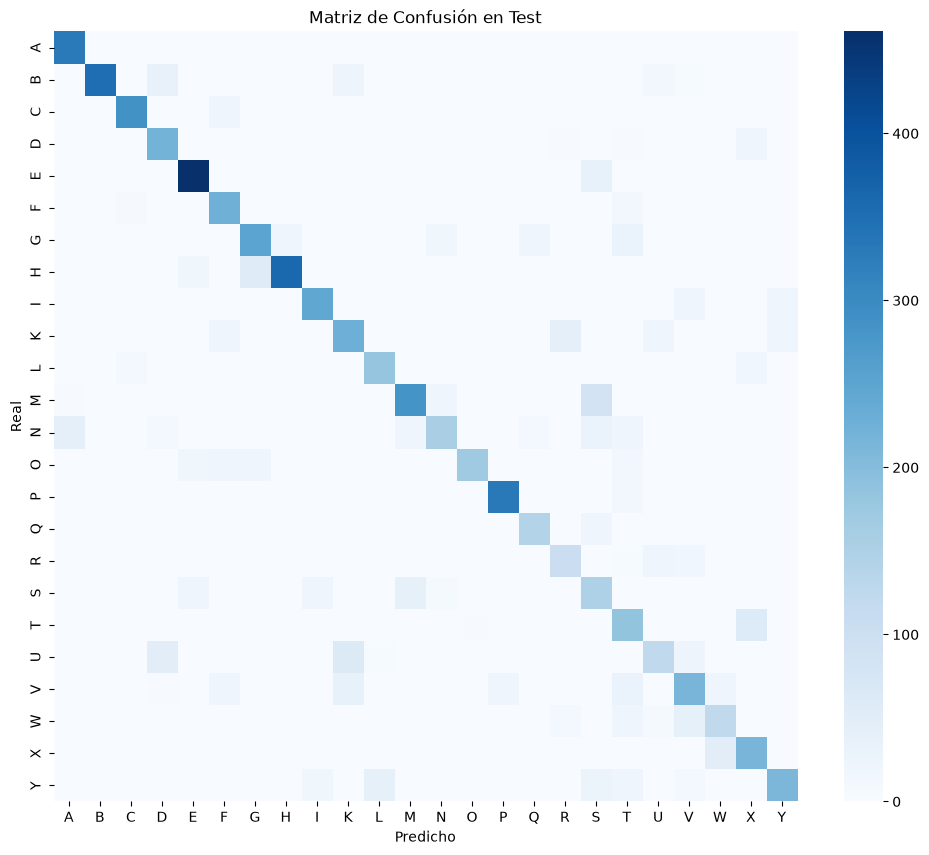

In [19]:

y_pred_probs = best_model.predict(X_test_final)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)
from sklearn.metrics import f1_score, precision_score, recall_score
acc = accuracy_score(y_true_classes, y_pred_classes)
f1m = f1_score(y_true_classes, y_pred_classes, average='macro')
print(f"Accuracy: {acc:.3f} | Precision macro: {precision_score(y_true_classes, y_pred_classes, average='macro'):.3f} "
      f"| Recall macro: {recall_score(y_true_classes, y_pred_classes, average='macro'):.3f} | F1 macro: {f1m:.3f}")
print(f"KPI Accuracy >= 0.80: {'CUMPLIDO' if acc>=0.80 else 'NO CUMPLIDO'} | KPI F1 macro >= 0.75: {'CUMPLIDO' if f1m>=0.75 else 'NO CUMPLIDO'}")
print(classification_report(y_true_classes, y_pred_classes, target_names=list(label_mapping.values())))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(label_mapping.values()), yticklabels=list(label_mapping.values()))
plt.title('Matriz de Confusión en Test')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.savefig('images/matriz_confusion_test.png')
plt.show()

### 5.4 Análisis de Errores
Calculamos empíricamente cuáles son los pares de letras más confundidos por la red neuronal.

In [20]:
# Buscar top 3 confusiones
errores = []
for i in range(len(y_true_classes)):
    if y_true_classes[i] != y_pred_classes[i]:
        # Convert binarized index back to original label using lb.classes_
        real_label_original = lb.classes_[y_true_classes[i]]
        pred_label_original = lb.classes_[y_pred_classes[i]]

        real_label = label_mapping[real_label_original]
        pred_label = label_mapping[pred_label_original]
        errores.append((real_label, pred_label))

from collections import Counter
conteo_errores = Counter(errores)
print("Top 5 confusiones más frecuentes (Real, Predicción):")
for par, cantidad in conteo_errores.most_common(5):
    print(f"La letra '{par[0]}' se confundió con '{par[1]}' -> {cantidad} veces")

Top 5 confusiones más frecuentes (Real, Predicción):
La letra 'M' se confundió con 'S' -> 86 veces
La letra 'U' se confundió con 'K' -> 63 veces
La letra 'T' se confundió con 'X' -> 60 veces
La letra 'H' se confundió con 'G' -> 56 veces
La letra 'U' se confundió con 'D' -> 50 veces


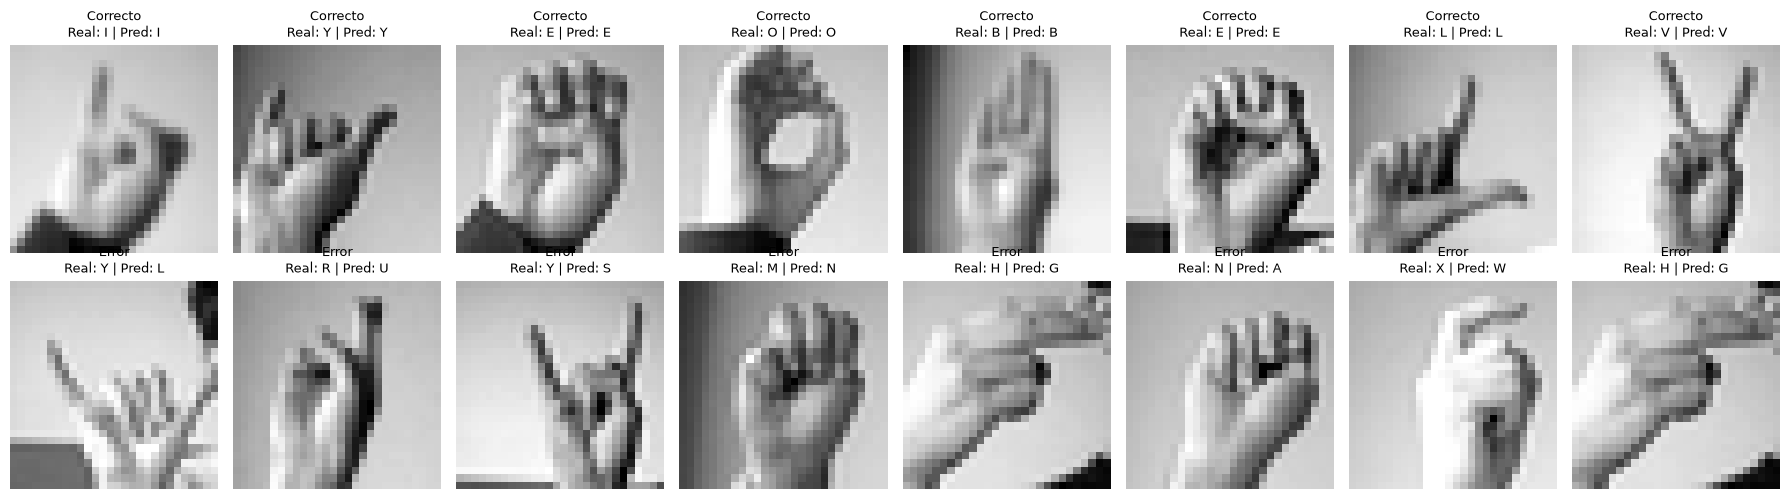

In [21]:
idx2letra = {i: label_mapping[l] for i, l in enumerate(lb.classes_)}
rng = np.random.default_rng(SEED)
idx_ok  = rng.choice(np.where(y_true_classes == y_pred_classes)[0], 8, replace=False)
idx_err = rng.choice(np.where(y_true_classes != y_pred_classes)[0], 8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for fila, (idxs, titulo) in enumerate([(idx_ok, 'Correcto'), (idx_err, 'Error')]):
    for j, i in enumerate(idxs):
        axes[fila, j].imshow(X_test_final[i].reshape(28, 28), cmap='gray')
        axes[fila, j].set_title(f"{titulo}\nReal: {idx2letra[y_true_classes[i]]} | Pred: {idx2letra[y_pred_classes[i]]}", fontsize=9)
        axes[fila, j].axis('off')
plt.tight_layout()
plt.savefig('images/ejemplos_clasificacion.png')
plt.show()

**Causas de los errores:** las confusiones más frecuentes son M→S (86 veces), U→K (63), T→X (60), H→G (56) y U→D (50). M y S son ambas formas de puño cerrado que solo difieren en la posición del pulgar, un detalle que a 28×28 px ocupa muy pocos píxeles. U, K y D comparten dedos extendidos en orientación parecida, y H y G tienen la misma orientación horizontal de la mano. Además, el MLP recibe los píxeles aplanados y no aprovecha la estructura espacial, por lo que depende de detalles exactos de posición.

### 5.5 Limitaciones del MLP: Experimento de Traslación
El principal problema del MLP es que al aplanar la imagen pierde la topología 2D: sus pesos están fijados a coordenadas absolutas de píxel. Para comprobarlo se desplazó todo el set de test horizontalmente y se midió el accuracy:

| Desplazamiento | 0 px | 1 px | 2 px | 4 px |
|---|---|---|---|---|
| Accuracy en test | 77,6% | 70,0% | 51,3% | 21,2% |

Un movimiento de solo 4 píxeles (14% del ancho de la imagen) destruye el rendimiento, pese a que para una persona la seña sigue siendo la misma letra. Una CNN, con filtros compartidos, sería mucho más robusta a este cambio.

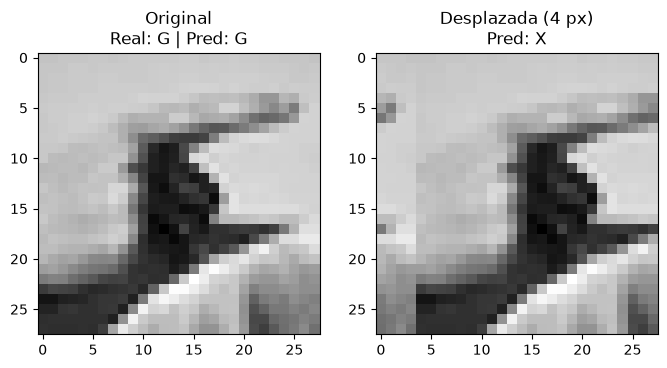

Desplazamiento 0 px -> Accuracy test: 0.776
Desplazamiento 1 px -> Accuracy test: 0.700
Desplazamiento 2 px -> Accuracy test: 0.513
Desplazamiento 4 px -> Accuracy test: 0.212


In [22]:
idx2letra = {i: label_mapping[l] for i, l in enumerate(lb.classes_)}

correct_idx = np.where(y_true_classes == y_pred_classes)[0][0]
img_original = X_test_final[correct_idx].reshape(28, 28)
img_desplazada = np.roll(img_original, shift=4, axis=1)
pred_orig = idx2letra[np.argmax(best_model.predict(img_original.reshape(1, 784), verbose=0))]
pred_desp = idx2letra[np.argmax(best_model.predict(img_desplazada.reshape(1, 784), verbose=0))]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original, cmap='gray'); axes[0].set_title(f"Original\nReal: {idx2letra[y_true_classes[correct_idx]]} | Pred: {pred_orig}")
axes[1].imshow(img_desplazada, cmap='gray'); axes[1].set_title(f"Desplazada (4 px)\nPred: {pred_desp}")
plt.savefig('images/experimento_traslacion.png'); plt.show()

# Efecto sobre TODO el test
for s in [0, 1, 2, 4]:
    X_s = np.roll(X_test_final.reshape(-1, 28, 28), shift=s, axis=2).reshape(-1, 784)
    a = accuracy_score(y_true_classes, np.argmax(best_model.predict(X_s, verbose=0), axis=1))
    print(f"Desplazamiento {s} px -> Accuracy test: {a:.3f}")

## FASE 6: Conclusiones

* **Desempeño:** el mejor modelo (**Profundo 256-128**, elegido por val_loss) alcanza **77,6%** de accuracy y **0,763** de F1 macro en test. Se cumple el KPI de F1 macro (≥ 75%) y no se cumple el de accuracy (≥ 80%).
* **Decisiones de diseño:** se compararon 3 arquitecturas. Agregar una segunda capa oculta subió el accuracy de validación de **87,9%** a **99,7%** (y el de test de 67,0% a 77,6%). El Dropout **no ayudó**: obtuvo 89,0% en validación y 69,8% en test, porque con solo 30 épocas la red ya estaba subajustada y la regularización frenó aún más el aprendizaje sin necesidad.
* **Fortalezas:** entrenamiento rápido, pipeline reproducible (semilla 42, split estratificado, test aislado para evitar leakage).
* **Limitaciones:** las clases con menor F1 son **S (0,51), U (0,55), T (0,61) y W (0,62)**, por gestos casi idénticos a baja resolución. Con un desplazamiento de solo 4 px, el accuracy cae de **77,6%** a **21,2%**, porque el MLP aplana la imagen y pierde la topología 2D. Además, el accuracy de validación (99,7%) supera por mucho al de test, lo que indica que la validación no es independiente de las manos del entrenamiento.
* **Mejoras futuras:** CNN (filtros compartidos, invariancia a traslación), data augmentation (rotaciones, desplazamientos), usar el 100% de los datos, separar validación por persona o mano y probar imágenes con fondos y tonos de piel variados (sesgo señalado en la Fase 1).